# Validação do Solver de Homogeneização (Darcy)

Testes de sanidade independentes do pipeline de geração/produção (`fina_note.ipynb` -> `teste_Geral.ipynb`). Usa as MESMAS funções (`pore_scale_utils.py`) que o notebook de produção, então validar aqui garante que o solver real está correto -- não uma cópia dele.

Não depende de carregar as 100 amostras -- é rápido de rodar rsrsr.

Nisso testamos 

#### A1: física dos limites está certa (poro puro / sólido puro)
#### A2: geometria/orientação está certa (sem viés de eixo)
#### A4: convergência de malha (resolução suficiente)

In [21]:
import sys
import pickle

import firedrake as fd
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, ".")

from pore_scale_utils import (
    criar_malha,
    build_permeability,
    preparar_espaco_pressao,
    resolver_keff,
)

print("Módulo pore_scale_utils importado com sucesso.")

Módulo pore_scale_utils importado com sucesso.


## Parâmetros de teste

Usando a mesma escala física do dataset de produção (`shape=(500,500)`, `voxel_size_m=(40e-6, 40e-6)`).

In [22]:
shape = (200, 200)
voxel_size_m = (40.0e-6, 40.0e-6)
k_solido = 1e-10
k_poro = 1.0

Ny_test, Nx_test = shape
malha_test, Lx_test, Ly_test = criar_malha(Nx_test, Ny_test, voxel_size_m)


V_perm_test = fd.FunctionSpace(malha_test, "DQ", 0)

print(f"Malha de teste: {Nx_test} x {Ny_test} células")
print(f"Domínio físico: Lx = {Lx_test*1e3:.4f} mm, Ly = {Ly_test*1e3:.4f} mm")

Malha de teste: 200 x 200 células
Domínio físico: Lx = 8.0000 mm, Ly = 8.0000 mm


## A1) Casos-limite: 100% poro e 100% sólido

Se o solver/malha/BC estiverem corretos, o domínio 100% poro deve dar `Keff ≈ k_poro`, e o domínio 100% sólido deve dar `Keff ≈ k_solido`.

In [23]:
void_todo_poro = np.ones((Ny_test, Nx_test), dtype=bool)
void_todo_solido = np.zeros((Ny_test, Nx_test), dtype=bool)

K_poro_puro = build_permeability(void_todo_poro, V_perm_test, Nx_test, Ny_test, Lx_test, Ly_test, k_solido, k_poro)
K_solido_puro = build_permeability(void_todo_solido, V_perm_test, Nx_test, Ny_test, Lx_test, Ly_test, k_solido, k_poro)

V_p_test, u_test, v_test, n_test = preparar_espaco_pressao(malha_test)

saida_poro = resolver_keff(malha_test, K_poro_puro, Lx_test, Ly_test, V_p=V_p_test, u=u_test, v=v_test, n=n_test)
saida_solido = resolver_keff(malha_test, K_solido_puro, Lx_test, Ly_test, V_p=V_p_test, u=u_test, v=v_test, n=n_test)


In [24]:

print("=== Caso 100% poro ===")
print(f"  Keff_x = {saida_poro['keff_x']:.6e}  (esperado ~ k_poro = {k_poro:.2e})")
print(f"  Keff_y = {saida_poro['keff_y']:.6e}")


print("=== Caso 100% sólido ===")
print(f"  Keff_x = {saida_solido['keff_x']:.6e}  (esperado ~ k_solido = {k_solido:.2e})")
print(f"  Keff_y = {saida_solido['keff_y']:.6e}")

erro_poro = abs(saida_poro["keff_x"] - k_poro) / k_poro
erro_solido = abs(saida_solido["keff_x"] - k_solido) / k_solido
print(f"\nErro relativo (poro puro):   {erro_poro:.20%}")
print(f"Erro relativo (sólido puro): {erro_solido:.20%}")

assert erro_poro < 0.05, "Caso 100% poro fugiu muito de k_poro -- checar BC/malha"
assert erro_solido < 0.05, "Caso 100% sólido fugiu muito de k_solido -- checar BC/malha"

=== Caso 100% poro ===
  Keff_x = 9.999995e-01  (esperado ~ k_poro = 1.00e+00)
  Keff_y = 9.999995e-01
=== Caso 100% sólido ===
  Keff_x = 9.999995e-11  (esperado ~ k_solido = 1.00e-10)
  Keff_y = 9.999995e-11

Erro relativo (poro puro):   0.00005038915610322547%
Erro relativo (sólido puro): 0.00005038908973653444%


## A2) Simetria de rotação

Pega uma amostra real (precisa apontar para o `.pkl` de produção) e testa se girar 90° troca `Keff_x` <-> `Keff_y`. Se `periodic=True` na geração, pequenas diferenças aqui são esperadas (rot90 não preserva periodicidade automaticamente).

In [25]:
# ajustar o caminho a pasta do seu arquivo .pkl
caminho_pkl = "/home/dairsonalbert/Pos-Graduacao-LNCC/2026_2/EDP/trabalho_final_implimentacao/voids/notebooks_final/Final_jair_final/final_data_final/training_data_3000.pkl"

try:
    with open(caminho_pkl, "rb") as f:
        data = pickle.load(f)
except FileNotFoundError:
    print(f"Aviso: '{caminho_pkl}' não encontrado neste diretório.")


In [26]:
idx_teste = 0
void_original = np.asarray(data["cases"][idx_teste].void, dtype=bool)
void_rotado = np.rot90(void_original)

K_original = build_permeability(void_original, V_perm_test, Nx_test, Ny_test, Lx_test, Ly_test, k_solido, k_poro)
K_rotado = build_permeability(void_rotado, V_perm_test, Nx_test, Ny_test, Lx_test, Ly_test, k_solido, k_poro)

s_orig = resolver_keff(malha_test, K_original, Lx_test, Ly_test, V_p=V_p_test, u=u_test, v=v_test, n=n_test)
s_rot = resolver_keff(malha_test, K_rotado, Lx_test, Ly_test, V_p=V_p_test, u=u_test, v=v_test, n=n_test)

In [27]:

print(f"Original:   Keff_x={s_orig['keff_x']:.4e}  Keff_y={s_orig['keff_y']:.4e}")
print(f"Rotado 90°: Keff_x={s_rot['keff_x']:.4e}  Keff_y={s_rot['keff_y']:.4e}")

erro_x = abs(s_rot["keff_x"] - s_orig["keff_y"]) / s_orig["keff_y"]
erro_y = abs(s_rot["keff_y"] - s_orig["keff_x"]) / s_orig["keff_x"]
print(f"\nEsperado: Keff_x(rotado) ~ Keff_y(original) -> erro = {erro_x:.20%}")
print(f"Esperado: Keff_y(rotado) ~ Keff_x(original) -> erro = {erro_y:.20%}")


Original:   Keff_x=5.4562e-09  Keff_y=3.4499e-09
Rotado 90°: Keff_x=3.4499e-09  Keff_y=5.4562e-09

Esperado: Keff_x(rotado) ~ Keff_y(original) -> erro = 0.00210599172872164616%
Esperado: Keff_y(rotado) ~ Keff_x(original) -> erro = 0.00015521296785039201%


## A3) Convergência de malha (refino dentro de cada voxel)

Testa se `Nx = Ny = 200` (1 célula FEM por voxel) já é fino o bastante, ou se o gradiente de pressão próximo às interfaces poro/sólido precisa de maior resolução.

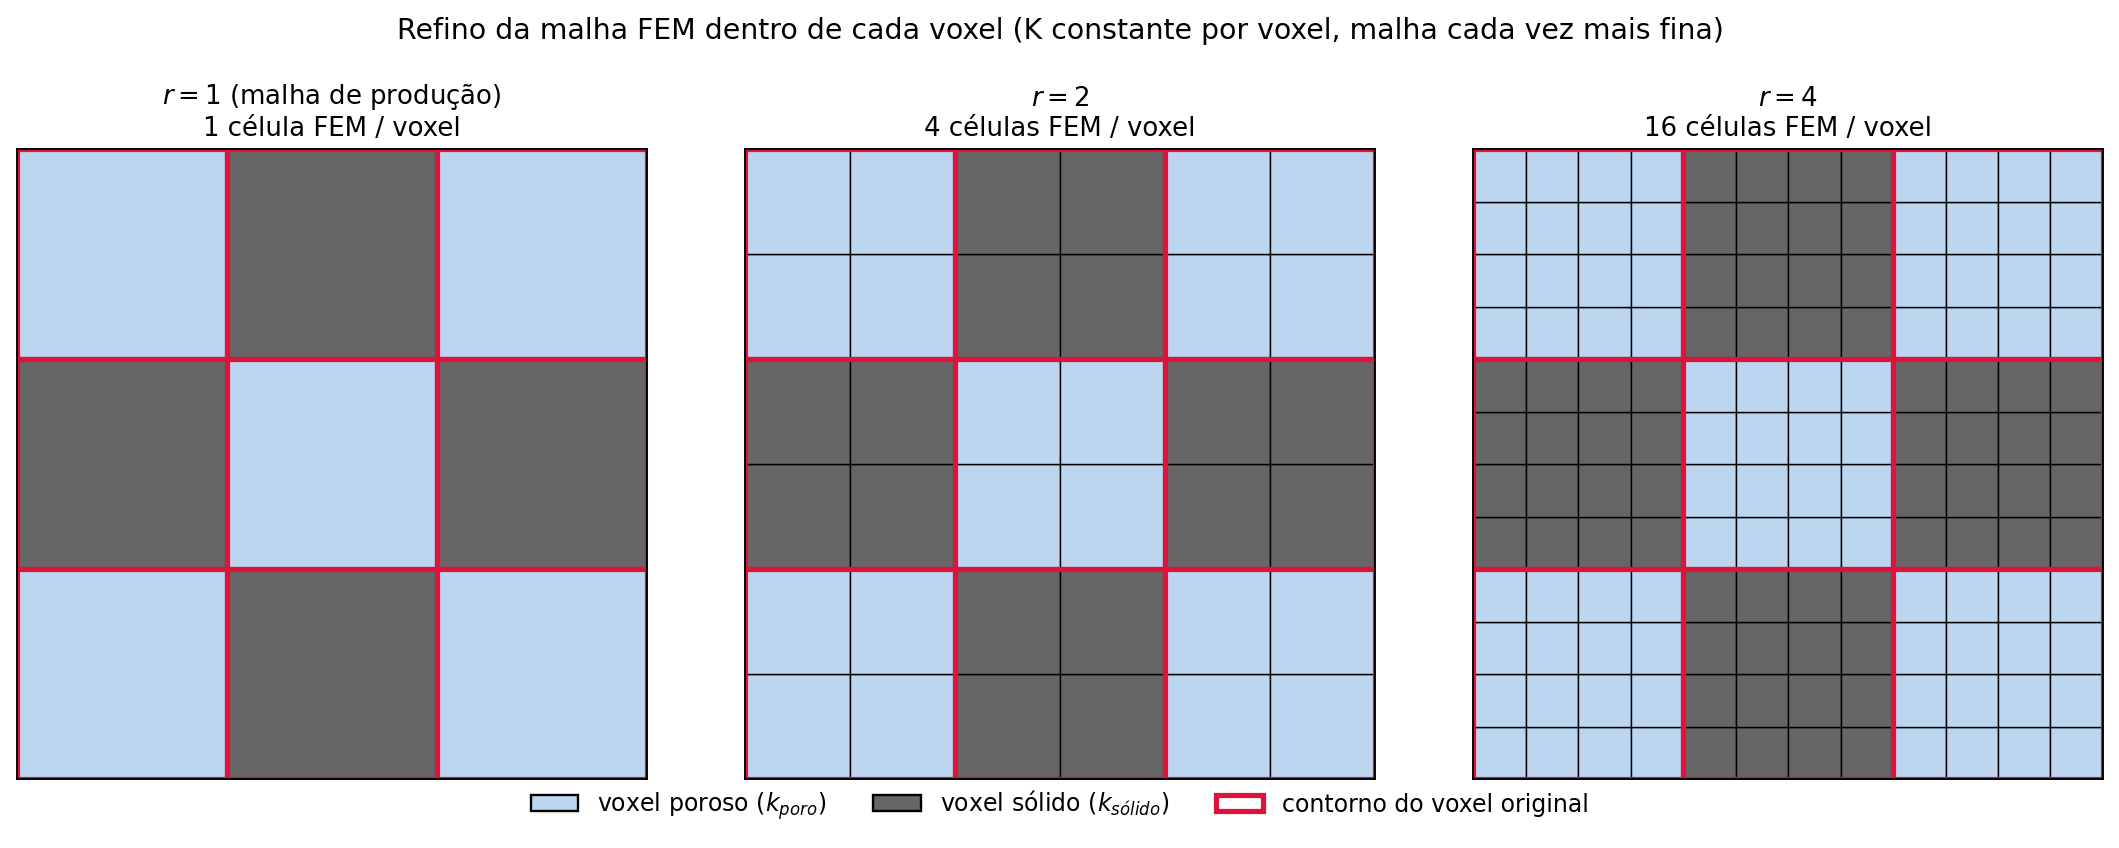

> **Aviso de custo:** o custo computacional é muito elevado. Não aplique esse nível de refino sem necessidade, especialmente para fatores elevados, como:
>
> ```python
> refinos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
>            11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
> ```
>
> Esse estudo deve ser utilizado apenas para verificar a convergência da malha.

In [28]:
def build_permeability_refinado(void_array, V_perm, Nx, Ny, Lx, Ly, refino, k_solido=1e-10, k_poro=1.0):
    """Como build_permeability, mas a malha tem Nx*refino x Ny*refino células,
    cada voxel do void mapeado para um bloco de refino x refino células FEM.
    
    """
    void_array = np.asarray(void_array, dtype=bool)
    K_numpy = np.where(void_array, k_poro, k_solido)

    malha_r = V_perm.mesh()
    K = fd.Function(V_perm, name="Permeabilidade")
    coords = fd.Function(fd.VectorFunctionSpace(malha_r, "DQ", 0))
    coords.interpolate(fd.SpatialCoordinate(malha_r))
    cx, cy = coords.dat.data[:, 0], coords.dat.data[:, 1]

    col = np.clip((cx / Lx * Nx).astype(int), 0, Nx - 1)
    row = np.clip((cy / Ly * Ny).astype(int), 0, Ny - 1)
    row_flipped = (Ny - 1) - row

    K.dat.data[:] = K_numpy[row_flipped, col]
    return K



# Recorte pequeno (50x50) para o teste de convergência ser rápido.
recorte = 50
void_pequeno = np.asarray(data["cases"][0].void, dtype=bool)[:recorte, :recorte]
voxel_recorte = voxel_size_m  # mesmo tamanho físico de voxel

refinos = [1, 2, 4]

print(f"{'refino':>8} | {'n_celulas':>12} | {'Keff_x':>12} | {'Keff_y':>12}")
keffs_refino = []
for r in refinos:
    Nx_r, Ny_r = recorte * r, recorte * r
    Lx_r = recorte * voxel_recorte[0]
    Ly_r = recorte * voxel_recorte[1]
    malha_r = fd.RectangleMesh(Nx_r, Ny_r, Lx_r, Ly_r, quadrilateral=True)
    V_perm_r = fd.FunctionSpace(malha_r, "DQ", 0)
    K_r = build_permeability_refinado(void_pequeno, V_perm_r, recorte, recorte, Lx_r, Ly_r, r, k_solido, k_poro)
    s = resolver_keff(malha_r, K_r, Lx_r, Ly_r)
    keffs_refino.append((r, s["keff_x"], s["keff_y"]))
    print(f"{r:>8} | {Nx_r*Ny_r:>12} | {s['keff_x']:>12.4e} | {s['keff_y']:>12.4e}")


  refino |    n_celulas |       Keff_x |       Keff_y
       1 |         2500 |   1.6168e-01 |   1.4792e-01
       2 |        10000 |   1.6058e-01 |   1.4328e-01
       4 |        40000 |   1.6016e-01 |   1.4073e-01


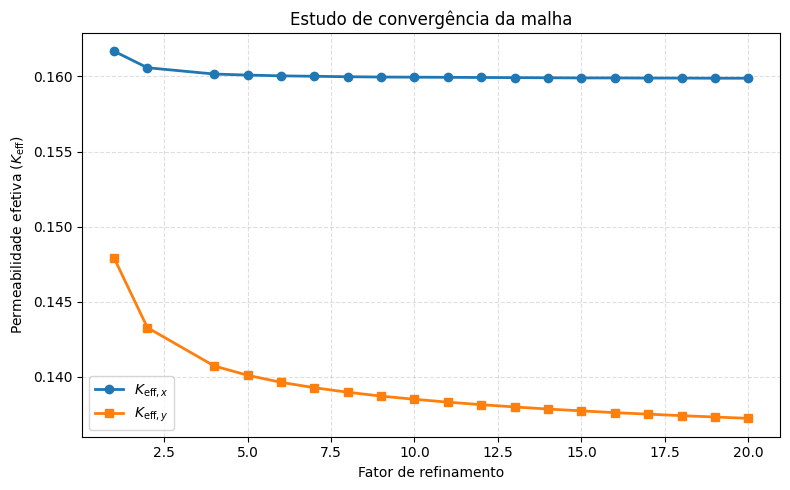

In [29]:
import matplotlib.pyplot as plt

# Dados
refino = [1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

n_celulas = [
    2500,10000,40000,62500,90000,122500,160000,202500,
    250000,302500,360000,422500,490000,562500,
    640000,722500,810000,902500,1000000
]

keff_x = [
    1.6168e-01,1.6058e-01,1.6016e-01,1.6009e-01,1.6004e-01,
    1.6001e-01,1.5998e-01,1.5996e-01,1.5995e-01,1.5994e-01,
    1.5993e-01,1.5992e-01,1.5991e-01,1.5990e-01,1.5990e-01,
    1.5989e-01,1.5989e-01,1.5988e-01,1.5988e-01
]

keff_y = [
    1.4792e-01,1.4328e-01,1.4073e-01,1.4011e-01,1.3964e-01,
    1.3928e-01,1.3898e-01,1.3872e-01,1.3851e-01,1.3832e-01,
    1.3815e-01,1.3800e-01,1.3786e-01,1.3774e-01,1.3762e-01,
    1.3752e-01,1.3742e-01,1.3733e-01,1.3724e-01
]

# ------------------------------
# Gráfico 1: Keff x Refino
# ------------------------------
plt.figure(figsize=(8,5))

plt.plot(refino, keff_x, 'o-', linewidth=2, markersize=6,
         label=r'$K_{\mathrm{eff},x}$')

plt.plot(refino, keff_y, 's-', linewidth=2, markersize=6,
         label=r'$K_{\mathrm{eff},y}$')

plt.xlabel('Fator de refinamento')
plt.ylabel(r'Permeabilidade efetiva ($K_{\mathrm{eff}}$)')
plt.title('Estudo de convergência da malha')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.savefig("/home/dairsonalbert/Pos-Graduacao-LNCC/2026_2/EDP/trabalho_final_implimentacao/voids/notebooks_final/Final_jair_final/final_data_final/convergencia_malha.png", dpi=300)
plt.tight_layout()
plt.show()